In [34]:
import pandas as pd

In [35]:
scenarios = ['scenario1.csv','scenario2.csv','scenario3.csv','scenario4.csv','scenario5.csv','scenario6.csv','scenario7.csv','scenario8.csv']

In [36]:
data_df = [pd.read_csv(i) for i in scenarios]

In [37]:
for i in range(len(data_df)):
    data_df[i]['scenario'] = i+1

In [38]:
full_df = pd.concat(data_df,ignore_index=True)

In [39]:
top_wait_duration = full_df.groupby('bridge_id').wait_duration.sum().sort_values(ascending = False).iloc[0:5]

In [43]:
for i in top_wait_duration.index:
    wait_event_count = full_df[full_df.bridge_id == i].bridge_id.value_counts().iloc[0]
    print(f'bridge with id {i} has kept {wait_event_count} trucks waiting over all the scenarios and replications')
    bridge_length = full_df[full_df.bridge_id == i].bridge_length.iloc[0]
    print(f'bridge with id {i} is {bridge_length} meters long')
    bridge_condition = full_df[full_df.bridge_id == i].bridge_condition.iloc[0]
    print(f'bridge with id {i} has condition {bridge_condition}')
    total_waiting_time = top_wait_duration.loc[i]
    print(f'bridge with id {i} has caused a total delay of {round(total_waiting_time)} minutes over all the scenarios and replications')

bridge with id 1002032.0 has kept 31986 trucks waiting over all the scenarios and replications
bridge with id 1002032.0 is 61.3 meters long
bridge with id 1002032.0 has condition D
bridge with id 1002032.0 has caused a total delay of 2157579 minutes over all the scenarios and replications
bridge with id 1002061.0 has kept 16310 trucks waiting over all the scenarios and replications
bridge with id 1002061.0 is 50.6 meters long
bridge with id 1002061.0 has condition C
bridge with id 1002061.0 has caused a total delay of 1101854 minutes over all the scenarios and replications
bridge with id 1002011.0 has kept 28524 trucks waiting over all the scenarios and replications
bridge with id 1002011.0 is 11.2 meters long
bridge with id 1002011.0 has condition D
bridge with id 1002011.0 has caused a total delay of 1070697 minutes over all the scenarios and replications
bridge with id 1001866.0 has kept 26021 trucks waiting over all the scenarios and replications
bridge with id 1001866.0 is 10.0 me

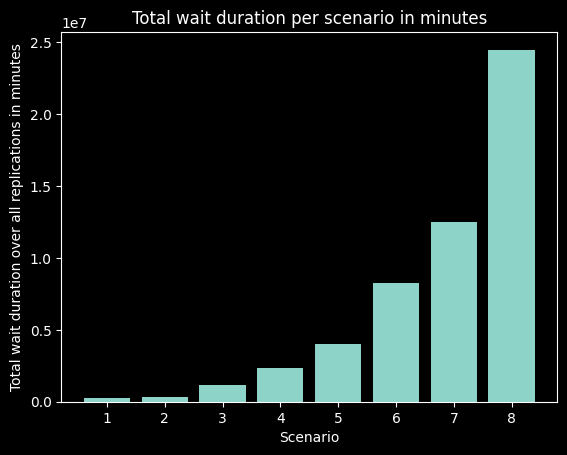

In [44]:
import matplotlib.pyplot as plt

data = full_df.groupby('scenario').wait_duration.sum()

fig, ax = plt.subplots()
ax.bar(data.index, data.values)

ax.set_ylabel('Total wait duration over all replications in minutes')
ax.set_xlabel('Scenario')
ax.set_title('Total wait duration per scenario in minutes')


plt.savefig("../img/total_wait_duration_per_scenario.png", dpi=300, bbox_inches='tight')

plt.show()
